# Embedding-Aware Mechanism Analysis

Standalone analysis notebook for the embedding-aware decoder mechanisms matrix (mechanism × injection × latent), plus the shuffled-latent control runs. Sits alongside `cross_folder_analysis.ipynb` — which stays as the project-wide overview — and goes deeper specifically on this ablation.

## Sections

1. **Setup and loading** — pulls run results via `_helpers.load_folder_results`, augments locally with matrix-axis columns and architecture parameters extracted from `best_model.pt`.
2. **Per-folder exhaustive summary tables** — every variant per (region, variable), via `_helpers.print_summary`. Equivalent of cross_folder section 2 but scoped to the matrix folders.
3. **Headline comparison per (region, variable)** — baselines + top-performing overall + best matrix variant + shuffled control. Paper-table-friendly.
4. **Matrix heatmap** *(scaffold; fills in once matrix results land)*.
5. **Injection × mechanism interaction panel** *(scaffold)*.
6. **Shuffled-control panel** *(scaffold)*.
7. **Mechanism diagnostics from `arch_params`** — learned decoder lengthscale, embed-stream lengthscale, attention temperature, kernel-cond shape-MLP frobenius norm.
8. **Cross-region summary** *(scaffold; fills in once southern_africa results land)*.
9. **P1 hooks** *(scaffold for per-condition / failure-mode analyses)*.

All matrix-specific code is local to this notebook. `_helpers.py` is touched only for the SetConv-baseline registration (one entry per (variable, distribution)).

## §1 Setup and loading

In [21]:
import json
import math
from pathlib import Path

import numpy as np
import pandas as pd

import _helpers as H

# Folders in scope for this analysis. Start with EU14y; add southern_africa
# once those runs land so §8 (cross-region summary) becomes meaningful.
FOLDERS = [
    "snapshot_14y_eu",
    "snapshot_14y_east_asia",  # uncomment when ready
]

SEEDS = (42, 123, 456)

frames = []
for folder in FOLDERS:
    df_f = H.load_folder_results(folder, seeds=SEEDS)
    if not df_f.empty:
        frames.append(df_f)
        print(f"  {folder}: {len(df_f)} run rows")
    else:
        print(f"  {folder}: no results yet")

df_raw = pd.concat(frames, ignore_index=True) if frames else pd.DataFrame()
print(f"\nTotal rows: {len(df_raw)}")

  snapshot_14y_eu: 963 run rows
  snapshot_14y_east_asia: 668 run rows

Total rows: 1631


### Architecture-parameter extraction (idempotent)

For each run in `df_raw`, load `best_model.pt`, pull the scalar architecture parameters out of the state_dict, and write them as `arch_params.json` alongside. CPU-only — no model instantiation needed, we read tensors by key directly.

Skips runs that already have an `arch_params.json` unless `OVERWRITE = True`. Safe to re-run; second pass is a no-op.

In [22]:
import torch  # CPU-only here; weights load to cpu via map_location

OVERWRITE = False

def _extract_arch_params_from_state_dict(sd: dict) -> dict:
    """Pull the scalar arch params + shape-MLP weights from a model state dict.

    Returns a dict with keys present only for mechanisms that were
    actually active in the run (RBFSetConv vs EmbeddingConditionedSetConv
    both populate `interp.log_scale`, so that field is always present).
    """
    out: dict = {}

    # Decoder SetConv lengthscale. RBFSetConv and EmbeddingConditionedSetConv
    # both expose `log_scale` (see convcnp.py:134 and convcnp.py:304).
    if "interp.log_scale" in sd:
        ls = sd["interp.log_scale"]
        out["decoder_log_scale"] = float(ls.item())
        out["decoder_length_scale"] = float(math.exp(ls.item()))

    # Kernel-cond shape MLP final layer.
    # The MLP is nn.Sequential(Linear(d, 32), ReLU, Linear(32, 2)) with
    # the last layer zero-initialised. Frobenius norm of the final weight
    # measures how far the MLP has moved from its zero-init: 0 = identical
    # to RBFSetConv, > 0 = the model has learned per-target deltas.
    shape_final_w = "interp.shape_mlp.2.weight"
    if shape_final_w in sd:
        w = sd[shape_final_w]
        out["shape_mlp_final_frobenius"] = float(torch.linalg.norm(w).item())
        # Stash the raw final-layer weights and bias too. Cheap (a few KB
        # per run) and lets later analyses compute per-station deltas
        # without re-loading the checkpoint.
        out["shape_mlp_final_weight"] = w.detach().cpu().numpy().tolist()
        b_key = "interp.shape_mlp.2.bias"
        if b_key in sd:
            out["shape_mlp_final_bias"] = sd[b_key].detach().cpu().numpy().tolist()

    # Embed-stream lengthscale (only present when --use-target-embed-stream).
    if "embed_stream.log_scale" in sd:
        ls = sd["embed_stream.log_scale"]
        out["embed_stream_log_scale"] = float(ls.item())
        out["embed_stream_length_scale"] = float(math.exp(ls.item()))

    # Attention parameters (only present when --target-embed-attention != none).
    if "embed_attention.log_temp" in sd:
        lt = sd["embed_attention.log_temp"]
        out["attn_log_temp"] = float(lt.item())
        out["attn_temp"] = float(math.exp(lt.item()))
    if "embed_attention.alpha_logit" in sd:  # hybrid mode only
        a = sd["embed_attention.alpha_logit"]
        out["attn_alpha"] = float(torch.sigmoid(a).item())
    if "embed_attention.log_spatial_scale" in sd:  # hybrid mode only
        ls = sd["embed_attention.log_spatial_scale"]
        out["attn_log_spatial_scale"] = float(ls.item())
        out["attn_spatial_scale"] = float(math.exp(ls.item()))

    return out


def extract_arch_params_in_run_dir(run_dir: Path, overwrite: bool = False) -> dict | None:
    """Read best_model.pt in run_dir, write arch_params.json sibling.

    Returns the extracted dict on success; None if there's no checkpoint
    or the file already exists and overwrite=False.
    """
    run_dir = Path(run_dir)

    # Gate: only process runs with completed evaluation. _helpers.py
    # uses the same signal in _load_run_record, so this keeps the
    # arch_params extraction and the metrics dataframe perfectly aligned.
    if not (run_dir / "test_summary.json").exists():
        return None
    
    out_path = run_dir / "arch_params.json"
    if out_path.exists() and not overwrite:
        return None

    pt_path = run_dir / "best_model.pt"
    if not pt_path.exists():
        return None

    ckpt = torch.load(pt_path, map_location="cpu", weights_only=False)
    sd = ckpt.get("model_state_dict", {})
    arch_params = _extract_arch_params_from_state_dict(sd)

    with open(out_path, "w") as f:
        json.dump(arch_params, f, indent=2)
    return arch_params


n_extracted = 0
n_skipped = 0
for run_dir_str in df_raw["run_dir"].unique():
    result = extract_arch_params_in_run_dir(Path(run_dir_str), overwrite=OVERWRITE)
    if result is None:
        n_skipped += 1
    else:
        n_extracted += 1

print(f"arch_params.json: {n_extracted} extracted, {n_skipped} skipped (already present or no checkpoint)")

arch_params.json: 0 extracted, 1631 skipped (already present or no checkpoint)


### Matrix-axis parsing and dataframe augmentation

Reads `config.json` for each run to identify which matrix cell it occupies (mechanism, injection, latent setting), reads `arch_params.json` for the architecture-internal scalars, attaches both as dataframe columns. The base `df_raw` is left untouched; this is a local augmentation for the matrix analyses below.

In [23]:
def parse_matrix_axes_from_config(config: dict) -> dict:
    """Map a config.json dict to the matrix axis labels used below.

    Mechanism levels:
      baseline / kernelcond / embedstream / kernelcond_embedstream /
      attnembed / hybridattn (the last is the already-run sibling).
    Injection levels:
      concat / noinj / film (the last only for legacy bilinear runs).
    Latent setting:
      none (no TESSERA), vae_lat16, vae_lat16_proj{N}[_mlp],
      vae_lat64_proj{N}[_mlp].
    """
    decoder_kernel = config.get("decoder_kernel", "isotropic")
    use_embed_stream = bool(config.get("use_target_embed_stream", False))
    attn_mode = config.get("target_embed_attention", "none")

    if decoder_kernel == "embedding_conditioned" and use_embed_stream:
        mech = "kernelcond_embedstream"
    elif decoder_kernel == "embedding_conditioned":
        mech = "kernelcond"
    elif use_embed_stream:
        mech = "embedstream"
    elif attn_mode == "embedding":
        mech = "attnembed"
    elif attn_mode == "hybrid":
        mech = "hybridattn"
    else:
        mech = "baseline"

    injection_raw = config.get("tessera_injection", "concat")
    injection = "noinj" if injection_raw == "none" else injection_raw

    proj_dim = int(config.get("vae_latents_proj_dim", 0) or 0)
    proj_mlp = bool(config.get("vae_latents_proj_mlp", False))
    vae_path = (config.get("vae_latents_path") or "")

    if not vae_path:
        latent_setting = "none"
    elif "lat64" in vae_path:
        latent_setting = f"vae_lat64_proj{proj_dim}" if proj_dim > 0 else "vae_lat64"
        if proj_mlp:
            latent_setting += "_mlp"
    else:
        if proj_dim > 0:
            latent_setting = f"vae_lat16_proj{proj_dim}"
            if proj_mlp:
                latent_setting += "_mlp"
        else:
            latent_setting = "vae_lat16"

    is_shuffled = "shuffle" in vae_path.lower()

    return {
        "mechanism": mech,
        "injection": injection,
        "latent_setting": latent_setting,
        "is_shuffled": is_shuffled,
        "interpolation": config.get("interpolation", "setconv"),
        "vae_latents_proj_dim": proj_dim,
        "vae_latents_proj_mlp": proj_mlp,
    }


def _load_json_safe(p: Path) -> dict:
    if not p.exists():
        return {}
    try:
        with open(p) as f:
            return json.load(f)
    except (json.JSONDecodeError, OSError):
        return {}


def add_matrix_columns_to_df(df: pd.DataFrame) -> pd.DataFrame:
    """Augment df with matrix-axis columns + arch_params columns.

    Reads config.json and arch_params.json for each row's run_dir. Returns
    a new dataframe; the input is not modified.
    """
    if df.empty:
        return df.copy()

    matrix_cols = []
    arch_cols = []
    for run_dir_str in df["run_dir"]:
        run_dir = Path(run_dir_str)
        config = _load_json_safe(run_dir / "config.json")
        matrix_cols.append(parse_matrix_axes_from_config(config))
        arch_cols.append(_load_json_safe(run_dir / "arch_params.json"))

    matrix_df = pd.DataFrame(matrix_cols)
    arch_df = pd.DataFrame(arch_cols)
    # Drop heavy fields from the dataframe view (raw shape-MLP weights);
    # they're still on disk in arch_params.json for §7 diagnostics.
    for heavy in ("shape_mlp_final_weight", "shape_mlp_final_bias"):
        if heavy in arch_df.columns:
            arch_df = arch_df.drop(columns=[heavy])

    return pd.concat(
        [df.reset_index(drop=True), matrix_df.reset_index(drop=True), arch_df.reset_index(drop=True)],
        axis=1,
    )


df = add_matrix_columns_to_df(df_raw)
print(f"Augmented dataframe: {len(df)} rows × {len(df.columns)} columns")
print("\nNew columns added by matrix-axis parsing:")
added = [c for c in df.columns if c not in df_raw.columns]
for c in added:
    print(f"  {c}")

Augmented dataframe: 1631 rows × 117 columns

New columns added by matrix-axis parsing:
  mechanism
  injection
  latent_setting
  is_shuffled
  interpolation
  vae_latents_proj_dim
  vae_latents_proj_mlp
  decoder_log_scale
  decoder_length_scale
  shape_mlp_final_frobenius
  embed_stream_log_scale
  embed_stream_length_scale
  attn_log_temp
  attn_temp
  attn_alpha
  attn_log_spatial_scale
  attn_spatial_scale


In [24]:
# Sanity check: how many runs do we have per (region, mechanism, injection, latent)?
if not df.empty:
    cell_counts = (
        df.groupby(["source_folder", "mechanism", "injection", "latent_setting", "is_shuffled"])
          .size()
          .rename("n_runs")
          .reset_index()
    )
    print(f"Distinct matrix cells observed: {len(cell_counts)}")
    cell_counts.head(30)

Distinct matrix cells observed: 96


## §2 Per-folder exhaustive summary tables

Same shape as cross_folder_analysis section 2 — every variant per (region, variable), printed via the existing `_helpers.print_summary`. Useful as the comprehensive reference view; the rest of the notebook focuses on selected slices and aggregations.

In [25]:
# Print one table per (folder, variable). Distribution is auto-inferred from
# `<var>_distribution` in the dataframe; for this matrix everything is Gaussian.
for folder in df["source_folder"].unique() if not df.empty else []:
    folder_df = df[df["source_folder"] == folder]
    for variable in ("wind", "t2m"):
        var_df = folder_df[folder_df["variables"].apply(lambda vs: variable in vs)]
        if var_df.empty:
            continue
        H.print_summary(
            var_df,
            variable=variable,
            title_suffix=f" — {folder}",
            region=folder,
        )


ConvCNP RESULTS — wind   [ — snapshot_14y_eu]   (snapshot_14y_eu)
Experiment                                                             MAE          RMSE     NLL(test)    Epoch  Pred σ     1σ%     2σ%  Seeds         N Stations   st/Mkm²
---------------------------------------------------------------------------------------------------------------------------------------------------------------------------
Wind snap bilinear baseline (with elev, with static,           1.287±0.001   1.875±0.007   1.845±0.005     3±0    1.60    69.9    94.7      3    678.8K      558         —
wd=1e-4)                                                    
Wind snap VAE-lat16 concat (with elev, no static, wd=1e-4)     1.217±0.009   1.762±0.007   1.802±0.009     5±0    1.52    70.5    95.1      3    678.8K      558         —
Wind snap VAE-lat16 concat (no elev, no static, wd=1e-4)       1.268±0.008   1.817±0.021   1.856±0.011     6±2    1.57    69.8    94.6      3    659.0K        —         —
Wind snap VAE-l

## §3 Headline comparison per (region, variable)

Compact table containing the references one needs to read the matrix results in context:

- *Simple baselines* (no learnable parameters): ERA5 interpolation, persistence.
- *No-TESSERA trained baselines*: ConvCNP + bilinear (no TESSERA), ConvCNP + SetConv (no TESSERA).
- *Existing best TESSERA variant* across all entries that ran before this matrix (e.g. the lat16→proj8-MLP FiLM row from prior sweeps).
- *Best matrix variant*: min-MAE-over-seeds among the new matrix cells (excluding shuffled).
- *Best matrix variant — shuffled control*: same architecture, shuffled latents.

Built dynamically from the augmented dataframe — no hand-crafted variant lists.

In [26]:
def _aggregate_over_seeds(rows: pd.DataFrame, variable: str, metric: str) -> tuple[float, float, int]:
    """Return (mean, std, n) of <variable>_<metric> across the seed rows."""
    col = f"{variable}_{metric}"
    if col not in rows.columns:
        return (float("nan"), float("nan"), 0)
    vals = pd.to_numeric(rows[col], errors="coerce").dropna()
    if vals.empty:
        return (float("nan"), float("nan"), 0)
    return (float(vals.mean()), float(vals.std(ddof=0)) if len(vals) > 1 else 0.0, int(len(vals)))


def headline_comparison_table(
    df: pd.DataFrame,
    region: str,
    variable: str,
    distribution: str = "gaussian",
    primary_metric: str = "mae",
) -> pd.DataFrame:
    """Build a single headline-comparison table for (region, variable).

    Selection logic:
      - Baselines: from H.baselines_for(variable, distribution).
      - Existing best TESSERA variant: min by primary_metric among rows where
        is_tessera is True, NOT in the new matrix (heuristic: NOT in any of
        the mechanism levels introduced by the matrix), and NOT shuffled.
      - Best matrix variant: min by primary_metric among rows where
        mechanism IS in the matrix levels and NOT shuffled.
      - Shuffled control: the shuffled-latent run of the same architecture.
    """
    folder_df = df[df["source_folder"] == region]
    var_df = folder_df[folder_df["variables"].apply(lambda vs: variable in vs)]
    var_df = var_df[var_df.get(f"{variable}_distribution", "gaussian") == distribution]
    if var_df.empty:
        return pd.DataFrame()

    metric_col = f"{variable}_{primary_metric}"
    rows_out = []

    # ---- Baselines ----
    for bname in H.baselines_for(variable, distribution):
        bdf = var_df[var_df["experiment"] == bname]
        if bdf.empty:
            continue
        mean, std, n = _aggregate_over_seeds(bdf, variable, primary_metric)
        rows_out.append({
            "category": "baseline",
            "experiment": bname,
            "label": bdf["label"].iloc[0],
            f"{primary_metric}_mean": mean,
            f"{primary_metric}_std": std,
            "n_seeds": n,
        })

    # ---- TESSERA non-matrix and matrix variants ----
    # Group by experiment, aggregate over seeds, then split into
    # "existing best" (legacy TESSERA, FiLM/bilinear etc.) vs matrix.
    NEW_MATRIX_MECHS = {"kernelcond", "embedstream", "kernelcond_embedstream", "attnembed"}
    is_baseline_name = var_df["experiment"].isin(H.baselines_for(variable, distribution))
    tessera_df = var_df[~is_baseline_name].copy()
    # Aggregate over seeds per experiment.
    if tessera_df.empty:
        per_exp = pd.DataFrame()
    else:
        per_exp = (
            tessera_df.groupby(["experiment", "label", "mechanism", "injection",
                                "latent_setting", "is_shuffled"], dropna=False)[metric_col]
                      .agg(["mean", "std", "count"])
                      .rename(columns={"mean": f"{primary_metric}_mean",
                                       "std": f"{primary_metric}_std",
                                       "count": "n_seeds"})
                      .reset_index()
        )
        per_exp[f"{primary_metric}_std"] = per_exp[f"{primary_metric}_std"].fillna(0.0)

    # Existing best TESSERA (legacy variants — not in the new matrix's mechanism
    # set and not shuffled).
    if not per_exp.empty:
        legacy_mask = (~per_exp["mechanism"].isin(NEW_MATRIX_MECHS)) & (~per_exp["is_shuffled"])
        legacy_df = per_exp[legacy_mask].dropna(subset=[f"{primary_metric}_mean"])
        if not legacy_df.empty:
            best = legacy_df.loc[legacy_df[f"{primary_metric}_mean"].idxmin()]
            rows_out.append({
                "category": "existing best TESSERA",
                "experiment": best["experiment"],
                "label": best["label"],
                f"{primary_metric}_mean": best[f"{primary_metric}_mean"],
                f"{primary_metric}_std": best[f"{primary_metric}_std"],
                "n_seeds": int(best["n_seeds"]),
            })

        # Best matrix variant (one of the four new mechanism levels, unshuffled).
        matrix_mask = per_exp["mechanism"].isin(NEW_MATRIX_MECHS) & (~per_exp["is_shuffled"])
        matrix_df = per_exp[matrix_mask].dropna(subset=[f"{primary_metric}_mean"])
        if not matrix_df.empty:
            best_matrix = matrix_df.loc[matrix_df[f"{primary_metric}_mean"].idxmin()]
            rows_out.append({
                "category": "best matrix variant",
                "experiment": best_matrix["experiment"],
                "label": best_matrix["label"],
                f"{primary_metric}_mean": best_matrix[f"{primary_metric}_mean"],
                f"{primary_metric}_std": best_matrix[f"{primary_metric}_std"],
                "n_seeds": int(best_matrix["n_seeds"]),
            })

            # Find its shuffled control by matching mechanism × injection.
            best_mech = best_matrix["mechanism"]
            best_inj = best_matrix["injection"]
            shuf_mask = (per_exp["mechanism"] == best_mech) & (per_exp["injection"] == best_inj) & per_exp["is_shuffled"]
            shuf_df = per_exp[shuf_mask].dropna(subset=[f"{primary_metric}_mean"])
            if not shuf_df.empty:
                shuf_row = shuf_df.iloc[0]
                rows_out.append({
                    "category": "best matrix variant (shuffled control)",
                    "experiment": shuf_row["experiment"],
                    "label": shuf_row["label"],
                    f"{primary_metric}_mean": shuf_row[f"{primary_metric}_mean"],
                    f"{primary_metric}_std": shuf_row[f"{primary_metric}_std"],
                    "n_seeds": int(shuf_row["n_seeds"]),
                })

    return pd.DataFrame(rows_out)


if not df.empty:
    for folder in df["source_folder"].unique():
        for variable in ("wind", "t2m"):
            table = headline_comparison_table(df, region=folder, variable=variable)
            if table.empty:
                continue
            print(f"\n=== {folder} / {variable} ===")
            print(table.to_string(index=False, float_format=lambda x: f"{x:.4f}"))


=== snapshot_14y_eu / wind ===
                              category                                                                         experiment                                                                             label  mae_mean  mae_std  n_seeds
                              baseline                                                     wind_snap_era5_interp_baseline                              Wind snap ERA5 interpolation (no model, sqrt(u²+v²))    1.4759   0.0000        3
                              baseline                                                     wind_snap_persistence_baseline                                Wind snap persistence (most recent valid obs ≤24h)    1.5457   0.0000        3
                              baseline                                                     wind_snap_bilinear_baseline_wd                     Wind snap bilinear baseline (with elev, with static, wd=1e-4)    1.2874   0.0011        3
                              baseline  

## §4 Matrix heatmap per (region, variable)  *(scaffold)*

5 mechanism levels × 6 (injection × latent setting) cells per panel. Colour by metric delta vs the no-TESSERA SetConv baseline; one panel per variable per region. To be filled in once the matrix has enough results to be meaningful (≥2 seeds per cell, say).

In [27]:
def matrix_view(
    df: pd.DataFrame,
    region: str,
    variable: str,
    metric: str = "mae",
    include_shuffled: bool = False,
) -> pd.DataFrame:
    """Pivot the matrix slice for (region, variable) into a (mechanism, injection × latent) table."""
    sub = df[(df["source_folder"] == region) &
             df["variables"].apply(lambda vs: variable in vs)]
    if not include_shuffled:
        sub = sub[~sub["is_shuffled"]]
    if sub.empty:
        return pd.DataFrame()

    metric_col = f"{variable}_{metric}"
    sub = sub[["mechanism", "injection", "latent_setting", metric_col]].dropna(subset=[metric_col])
    grouped = sub.groupby(["mechanism", "injection", "latent_setting"])[metric_col].mean().reset_index()
    # Combine injection and latent into one axis label for compact display.
    grouped["inj_x_latent"] = grouped["injection"] + " / " + grouped["latent_setting"]
    return grouped.pivot(index="mechanism", columns="inj_x_latent", values=metric_col)


# Example call (will return an empty frame until results land):
if not df.empty:
    for folder in df["source_folder"].unique():
        for variable in ("wind", "t2m"):
            mv = matrix_view(df, region=folder, variable=variable, metric="mae")
            if mv.empty:
                continue
            print(f"\n=== matrix view: {folder} / {variable} / MAE ===")
            print(mv.to_string(float_format=lambda x: f"{x:.4f}"))


=== matrix view: snapshot_14y_eu / wind / MAE ===
inj_x_latent            concat / none  concat / vae_lat16  concat / vae_lat16_proj8  concat / vae_lat16_proj8_mlp  concat / vae_lat64  concat / vae_lat64_proj16  concat / vae_lat64_proj16_mlp  concat / vae_lat64_proj32  concat / vae_lat64_proj32_mlp  concat / vae_lat64_proj8  concat / vae_lat64_proj8_mlp  film / vae_lat16  film / vae_lat16_proj8  film / vae_lat16_proj8_mlp  film / vae_lat64  film / vae_lat64_proj16  film / vae_lat64_proj16_mlp  film / vae_lat64_proj32  film / vae_lat64_proj32_mlp  film / vae_lat64_proj8  film / vae_lat64_proj8_mlp  noinj / vae_lat16  noinj / vae_lat16_proj8  noinj / vae_lat64_proj16
mechanism                                                                                                                                                                                                                                                                                                                            


=== matrix view: snapshot_14y_eu / t2m / MAE ===
inj_x_latent            concat / none  concat / vae_lat16  concat / vae_lat16_proj8  concat / vae_lat16_proj8_mlp  concat / vae_lat64  concat / vae_lat64_proj16  concat / vae_lat64_proj16_mlp  concat / vae_lat64_proj32  concat / vae_lat64_proj32_mlp  concat / vae_lat64_proj8  concat / vae_lat64_proj8_mlp  film / vae_lat16  film / vae_lat16_proj8  film / vae_lat16_proj8_mlp  film / vae_lat64  film / vae_lat64_proj16  film / vae_lat64_proj16_mlp  film / vae_lat64_proj32  film / vae_lat64_proj32_mlp  film / vae_lat64_proj8  film / vae_lat64_proj8_mlp  noinj / vae_lat16  noinj / vae_lat16_proj8  noinj / vae_lat64_proj16
mechanism                                                                                                                                                                                                                                                                                                                             

## §5 Injection × mechanism interaction panel  *(scaffold)*

For each mechanism in {kernelcond, embedstream, kernelcond_embedstream, attnembed}, plot two columns of points (concat vs noinj) with per-seed scatter and the no-TESSERA SetConv baseline as a horizontal reference. Tests whether the A2'-style result (noinj better than concat for embed-stream) generalises across mechanisms.

*(Plotting code stub here; fills in once seeds-per-cell ≥ 2 for the relevant cells.)*

## §6 Shuffled-control panel  *(scaffold)*

Per matrix cell that has a shuffled sibling, three points side-by-side: shuffled mean (with seed error bars), real mean (same architecture), no-TESSERA SetConv baseline mean. Interpretation guide rendered as cell annotations:

- *shuffled ≈ real* → capacity story (mechanism uses parameters, not station-specific signal).
- *shuffled ≈ baseline* → signal story (mechanism uses station-specific signal heavily).
- *intermediate* → partial signal usage.

*(Plotting code stub here.)*

## §7 Mechanism diagnostics from `arch_params`

What did the model actually learn — at the level of the structural parameters? Three diagnostics:

- **Decoder lengthscale** (`decoder_length_scale`): how locally the SetConv reads from the grid. Compare across mechanisms and across latent settings.
- **Embed-stream lengthscale** (`embed_stream_length_scale`): how far landscape information spreads from each station onto the grid. Compare to typical inter-station distance in the region.
- **Kernel-cond shape-MLP frobenius norm** (`shape_mlp_final_frobenius`): how far the per-target lengthscale modulation moved from its zero-init. 0 = mechanism collapsed to plain RBFSetConv; > 0 = the model actually used the per-target capacity.

In [28]:
if not df.empty:
    # Decoder lengthscale per mechanism (aggregated over seeds).
    diag_cols = [
        "source_folder", "mechanism", "injection", "latent_setting",
        "decoder_length_scale", "embed_stream_length_scale",
        "shape_mlp_final_frobenius", "attn_temp",
    ]
    present = [c for c in diag_cols if c in df.columns]
    if any(c in present for c in diag_cols[4:]):
        diag = df[present].copy()
        # Drop unshuffled / matrix-cells-only for cleaner reading.
        if "is_shuffled" in df.columns:
            diag = diag[~df["is_shuffled"]]
        print("Per-mechanism diagnostics (averaged over seeds and matrix-cell siblings):")
        summary = (diag.groupby(["source_folder", "mechanism"], dropna=False)
                       [[c for c in present if c not in ("source_folder", "mechanism", "injection", "latent_setting")]]
                       .agg(["mean", "std"]))
        print(summary.to_string(float_format=lambda x: f"{x:.4f}"))
    else:
        print("No arch_params data yet — extract cell above hasn't found any best_model.pt files.")

Per-mechanism diagnostics (averaged over seeds and matrix-cell siblings):
                                              decoder_length_scale        embed_stream_length_scale        shape_mlp_final_frobenius        attn_temp       
                                                              mean    std                      mean    std                      mean    std      mean    std
source_folder          mechanism                                                                                                                            
snapshot_14y_east_asia attnembed                            0.2980 0.1000                       NaN    NaN                       NaN    NaN    0.9059 0.0707
                       baseline                             0.2975 0.1059                       NaN    NaN                       NaN    NaN       NaN    NaN
                       embedstream                          0.2943 0.0952                    0.6001 0.1558                       NaN    NaN  

## §8 Cross-region summary  *(scaffold; waits on southern_africa)*

Once both regions are in: small table comparing (best matrix architecture, magnitude of gain over no-TESSERA, shuffled-control magnitude) across EU14y and southern_africa. Whether the gain scales with landscape heterogeneity is the paper's structural-equivariance claim.

## §9 P1 hooks  *(scaffold)*

Per-condition error stratification (terrain class, season, region within region) and failure-mode analysis (worst-stations, worst-conditions). Reads from `test_predictions.npz` and `test_station_errors.npz` rather than `test_summary.json`. Not in scope for the first version of this notebook; the scaffold marks where the analyses go.

Loading checkpoint: /lus/lfs1aip2/projects/u6do/pmms2/end-to-end-forecasting/projects/tessera_downscaling/.tmp_output/training_runs_snapshot_14y_eu/t2m_snap_vae_lat64_proj16_setconv_concat_attnembed_with_elev_no_static_wd_seed42/best_model.pt
  best epoch=29, val_loss=1.7235
  region resolved from folder: 'europe'
TESSERA filtering: centre-pixel-nonzero 36389/38870, coverage>=0.50 36396/38870, both 36384/38870
[europe] 1758/1851 stations after TESSERA filtering
VAE latents loaded: shape=(38870, 64), 35390/38870 non-NaN
[europe] 1758/1758 stations after VAE latent filtering
MultiRegionSnapshotDownscalingDataset(val): 1460 total episodes across 1 regions [europe:test]
TESSERA filtering: centre-pixel-nonzero 36389/38870, coverage>=0.50 36396/38870, both 36384/38870
[europe] 9878/10485 stations after TESSERA filtering
VAE latents loaded: shape=(38870, 64), 35390/38870 non-NaN
[europe] 9877/9878 stations after VAE latent filtering
MultiRegionSnapshotDownscalingDataset(val): 1460 total episo

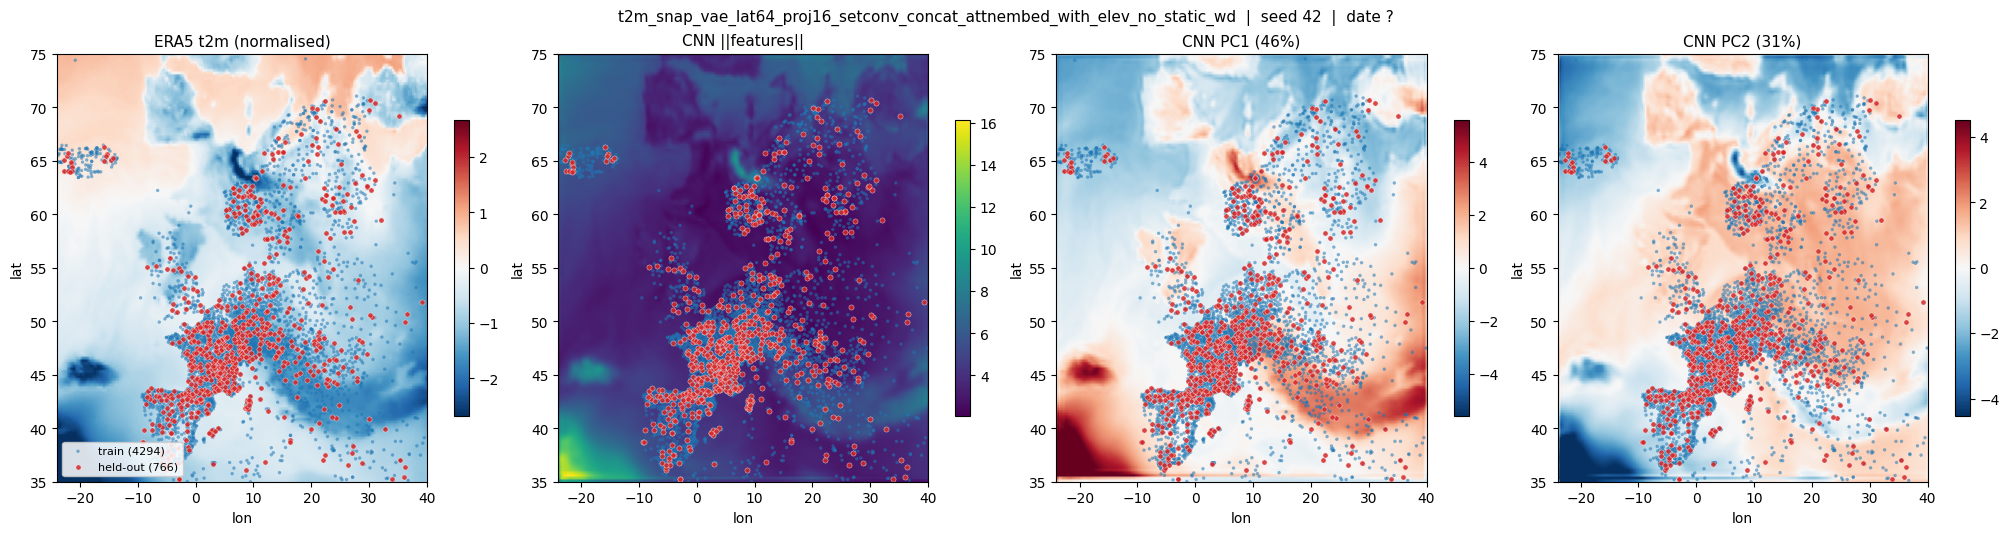

In [29]:
# ============================================================================
# Diagnostic: CNN feature-map structure vs training-station distribution
# ----------------------------------------------------------------------------
# Picks a trained model, runs the validation loader through model.cnn only
# (skipping the SetConv / decoder), and visualises the post-CNN grid feature
# map. Overlays both train-set and held-out-set station locations.
#
# The hypothesis being tested visually: does the CNN's output show spatial
# structure that tracks the training-station distribution beyond what ERA5
# spatial structure alone would explain? If so, that's evidence the CNN's
# filter shape is biased toward the train landscape, and target-conditioned
# kernel-cond at the decoder makes sense as compensation.
# ============================================================================

import sys
import json
import pickle
from pathlib import Path

import numpy as np
import torch
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader

# Bootstrap repo paths so we can import the model + dataset code.
_HELPERS_DIR = Path.cwd()
sys.path.insert(0, str(_HELPERS_DIR))
import _helpers as H

REPO_ROOT = H.find_repo_root()
SRC = REPO_ROOT / "projects" / "tessera_downscaling" / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

from tessera_downscaling.model.convcnp import ConvCNPDownscaler
from tessera_downscaling.data.dataset import (
    MultiRegionSnapshotDownscalingDataset,
    downscaling_collate,
)

# ----------------------------------------------------------------------------
# 1. Pick the run to load
# ----------------------------------------------------------------------------
# Top t2m performer in EU14y matrix screenshots: lat64→proj16 SetConv concat
# + attention-embedding (1.099 MAE). Fill in the exact experiment-name string
# matching your run dir (it should be in .tmp_output/training_runs_snapshot_14y_eu/).
FOLDER = "snapshot_14y_eu"
EXPERIMENT = "t2m_snap_vae_lat64_proj16_setconv_concat_attnembed_with_elev_no_static_wd"  # change if your name differs
SEED = 42

run_dir = H.output_dir_for_folder(FOLDER) / f"{EXPERIMENT}_seed{SEED}"
ckpt_path = run_dir / "best_model.pt"
assert ckpt_path.exists(), f"No checkpoint at {ckpt_path}"
print(f"Loading checkpoint: {ckpt_path}")

ckpt = torch.load(ckpt_path, map_location="cpu", weights_only=False)
config = ckpt["config"]
print(f"  best epoch={ckpt.get('epoch')}, val_loss={ckpt.get('val_loss'):.4f}")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ----------------------------------------------------------------------------
# 2. Rebuild the validation dataset (held-out stations) from saved config
# ----------------------------------------------------------------------------
def _as_bool(v, default=False):
    if v is None: return default
    if isinstance(v, bool): return v
    return str(v).lower() in ("true", "1", "yes")

def _as_int(v, default=0):
    if v in (None, "None", ""): return default
    return int(v)

def _as_path_or_none(v):
    if v in (None, "None", ""): return None
    return Path(v)

# ----------------------------------------------------------------------------
# 2. Resolve the region and rebuild val/train datasets
# ----------------------------------------------------------------------------
region = H._folder_to_region(FOLDER)
if region is None:
    raise RuntimeError(f"Could not resolve a region from folder {FOLDER!r}")
print(f"  region resolved from folder: {region!r}")

dataset_dir = Path(config["dataset_dir"])
assert dataset_dir.exists(), f"dataset_dir from config not found: {dataset_dir}"

# Shared kwargs (mirrors train.py's shared_kwargs build).
ds_kwargs = dict(
    dataset_dir=dataset_dir,
    regions=[region],
    target_variables=list(config["target_variables"]),
    tessera_path=_as_path_or_none(config.get("tessera_path")),
    tessera_station_csv=_as_path_or_none(config.get("tessera_station_csv")),
    load_tessera_patches=False,
    include_static_fields=_as_bool(config.get("include_static_fields"), False),
    vae_latents_path=Path(config["vae_latents_path"]),
    vae_latents_station_csv=Path(config["vae_latents_station_csv"]),
    vae_latents_zscore=not _as_bool(config.get("vae_latents_no_zscore"), False),
    min_patch_coverage=float(config.get("min_tessera_patch_coverage", 0.0)),
    normalisation_policy=config.get("normalisation_policy", "per_region"),
)

val_dataset = MultiRegionSnapshotDownscalingDataset(
    **ds_kwargs, split="val", station_split="test",   # held-out stations
)
train_dataset = MultiRegionSnapshotDownscalingDataset(
    **ds_kwargs, split="val", station_split="train",  # same dates, train stations
)
print(f"  val_dataset: {len(val_dataset)} episodes, "
      f"n_context_channels={val_dataset.n_context_channels}, "
      f"vae_latent_dim={val_dataset.vae_latent_dim}")

# ----------------------------------------------------------------------------
# 3. Build the model from saved config + dataset-derived dims
# ----------------------------------------------------------------------------
model = ConvCNPDownscaler(
    n_context_channels=val_dataset.n_context_channels,
    cnn_hidden=_as_int(config.get("cnn_hidden"), 128),
    cnn_layers=_as_int(config.get("cnn_layers"), 7),
    cnn_kernel=_as_int(config.get("cnn_kernel"), 3),
    setconv_length_scale=float(config.get("setconv_length_scale", 0.5)),
    interpolation=config.get("interpolation", "setconv"),
    mlp_hidden=_as_int(config.get("mlp_hidden"), 128),
    mlp_n_hidden=_as_int(config.get("mlp_n_hidden"), 3),
    n_elev_features=2,
    include_elevation=_as_bool(config.get("include_elevation"), True),
    target_variables=list(config["target_variables"]),
    likelihood_per_variable=dict(config.get(
        "likelihood_per_variable",
        {v: "gaussian" for v in config["target_variables"]},
    )),
    tessera_encoder=None,
    tessera_injection=config.get("tessera_injection", "concat"),
    tessera_features_precomputed=True,
    precomputed_tessera_dim=val_dataset.vae_latent_dim,
    precomputed_drop_prob=float(config.get("vae_latents_drop_prob", 0.0)),
    precomputed_proj_dim=_as_int(config.get("vae_latents_proj_dim"), 0),
    precomputed_proj_mlp=_as_bool(config.get("vae_latents_proj_mlp"), False),
    decoder_kernel=config.get("decoder_kernel", "isotropic"),
    use_target_embed_stream=_as_bool(config.get("use_target_embed_stream"), False),
    target_embed_attention=config.get("target_embed_attention", "none"),
).to(device)

missing, unexpected = model.load_state_dict(ckpt["model_state_dict"], strict=False)
if missing:    print(f"  [warn] missing keys: {missing[:5]}{' …' if len(missing) > 5 else ''}")
if unexpected: print(f"  [warn] unexpected keys: {unexpected[:5]}{' …' if len(unexpected) > 5 else ''}")
model.eval()

# ----------------------------------------------------------------------------
# 4. Grab one held-out batch and forward through the CNN only
# ----------------------------------------------------------------------------
loader = DataLoader(val_dataset, batch_size=1, shuffle=False,
                    num_workers=0, collate_fn=downscaling_collate)
batch = next(b for b in loader if b is not None)  # first non-empty episode
print(f"  episode date: {batch.get('date', '(n/a)')}, n_targets={batch['target_coords'].shape[1]}")

with torch.no_grad():
    context_grid = batch["context_grid"].to(device)            # (1, C, H, W)
    grid_features = model.cnn(context_grid)                     # (1, C_cnn, H, W)
    # ERA5 t2m channel index — by convention channel 0 in the snapshot
    # encoder is t2m. Verify against metadata.json if uncertain.
    era5_t2m = context_grid[0, 0].cpu().numpy()                 # (H, W)
    gf = grid_features[0].cpu().numpy()                         # (C_cnn, H, W)

C, Hh, Ww = gf.shape
feat_norm = np.linalg.norm(gf, axis=0)                          # (H, W)

# PCA across cells of the channel vectors.
flat = gf.reshape(C, -1).T                                       # (H*W, C)
flat = flat - flat.mean(axis=0, keepdims=True)
U, S, Vt = np.linalg.svd(flat, full_matrices=False)
pc1 = (flat @ Vt[0]).reshape(Hh, Ww)
pc2 = (flat @ Vt[1]).reshape(Hh, Ww)
print(f"  PCA: PC1 explains {(S[0]**2)/((S**2).sum()):.1%}, "
      f"PC2 explains {(S[1]**2)/((S**2).sum()):.1%} of feature variance")

# ----------------------------------------------------------------------------
# 5. Station coordinates for the overlay
# ----------------------------------------------------------------------------
# Held-out (this batch).
held_out_lats = batch["target_coords"][0, :, 0].numpy()
held_out_lons = batch["target_coords"][0, :, 1].numpy()
# Train stations: pull from the same-date episode in train_dataset to get a
# representative set of "stations the model saw during training". Other dates
# would give different counts due to data gaps, but the set is broadly stable.
train_loader = DataLoader(train_dataset, batch_size=1, shuffle=False,
                          num_workers=0, collate_fn=downscaling_collate)
train_batch = next(b for b in train_loader if b is not None)
train_lats = train_batch["target_coords"][0, :, 0].numpy()
train_lons = train_batch["target_coords"][0, :, 1].numpy()

grid_lats = batch["grid_lats"].numpy()
grid_lons = batch["grid_lons"].numpy()
extent = [grid_lons.min(), grid_lons.max(), grid_lats.min(), grid_lats.max()]

# ----------------------------------------------------------------------------
# 6. Plot
# ----------------------------------------------------------------------------
fig, axes = plt.subplots(1, 4, figsize=(20, 5), constrained_layout=True)
panels = [
    (era5_t2m,  "ERA5 t2m (normalised)", "RdBu_r"),
    (feat_norm, "CNN ||features||",      "viridis"),
    (pc1,       f"CNN PC1 ({(S[0]**2)/((S**2).sum()):.0%})", "RdBu_r"),
    (pc2,       f"CNN PC2 ({(S[1]**2)/((S**2).sum()):.0%})", "RdBu_r"),
]
for ax, (field, title, cmap) in zip(axes, panels):
    vmax = np.percentile(np.abs(field), 99) if cmap == "RdBu_r" else None
    vmin = -vmax if vmax is not None else None
    im = ax.imshow(field, extent=extent, origin="lower", aspect="auto",
                   cmap=cmap, vmin=vmin, vmax=vmax)
    ax.scatter(train_lons,    train_lats,    s=6, c="#1f77b4",
               alpha=0.55, edgecolors="none", label=f"train ({len(train_lats)})")
    ax.scatter(held_out_lons, held_out_lats, s=14, c="#d62728",
               alpha=0.85, edgecolors="white", linewidth=0.3,
               label=f"held-out ({len(held_out_lats)})")
    ax.set_title(title, fontsize=11)
    ax.set_xlabel("lon"); ax.set_ylabel("lat")
    fig.colorbar(im, ax=ax, fraction=0.04, shrink=0.85)
axes[0].legend(loc="lower left", fontsize=8, framealpha=0.85)
fig.suptitle(
    f"{EXPERIMENT}  |  seed {SEED}  |  date {batch.get('date', '?')}",
    fontsize=11, y=1.04,
)
plt.show()